# Pipeline Preditivo MNIST

Mini-projeto avaliativo — Módulo 2. Classificação multiclasse de dígitos manuscritos (MNIST),
com benchmark de 3 modelos e testes de robustez.


## Fase 1 — Carregamento e Análise Exploratória (EDA)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# --- Carregamento ---
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(np.uint8)   # X: float, y: string -> int

# --- Dimensionalidade ---
print("Formato de X:", X.shape)   # esperado (70000, 784)
print("Formato de y:", y.shape)   # esperado (70000,)
print("Intervalo de intensidade:", X.min(), "a", X.max())

Formato de X: (70000, 784)
Formato de y: (70000,)
Intervalo de intensidade: 0 a 255


dígito 0: 6903 exemplos
dígito 1: 7877 exemplos
dígito 2: 6990 exemplos
dígito 3: 7141 exemplos
dígito 4: 6824 exemplos
dígito 5: 6313 exemplos
dígito 6: 6876 exemplos
dígito 7: 7293 exemplos
dígito 8: 6825 exemplos
dígito 9: 6958 exemplos


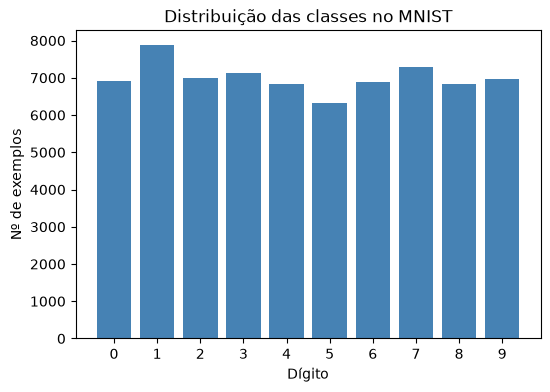

Mínimo por classe: 6313 | Máximo por classe: 7877 | Razão max/min: 1.25


In [2]:
# --- Distribuição das classes ---
valores, contagens = np.unique(y, return_counts=True)
for v, c in zip(valores, contagens):
    print(f"dígito {v}: {c} exemplos")

plt.figure(figsize=(6, 4))
plt.bar(valores, contagens, color="steelblue")
plt.xlabel("Dígito")
plt.ylabel("Nº de exemplos")
plt.title("Distribuição das classes no MNIST")
plt.xticks(valores)
plt.show()

print(f"Mínimo por classe: {contagens.min()} | Máximo por classe: {contagens.max()} "
      f"| Razão max/min: {contagens.max()/contagens.min():.2f}")

**TODO (você escreve):** com base nos números acima, afirme explicitamente se o dataset está
balanceado entre as 10 classes (compare o mínimo e o máximo de exemplos por classe).

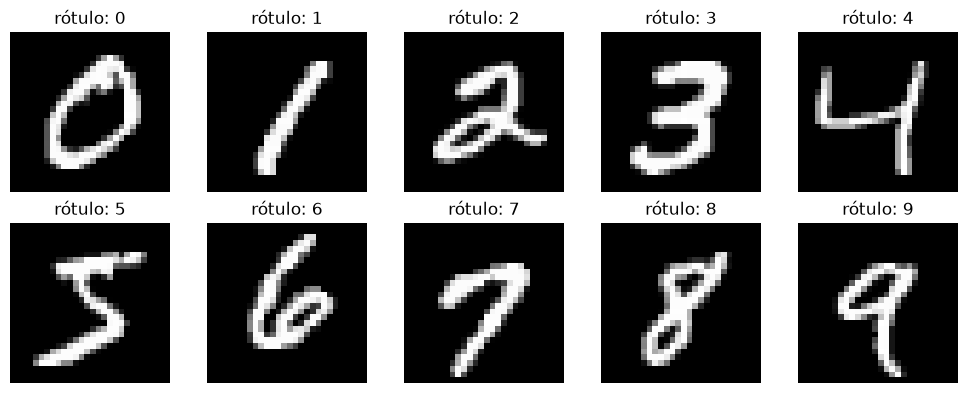

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digito, ax in zip(range(10), axes.ravel()):
    idx = np.where(y == digito)[0][0]     # primeiro índice desse dígito
    ax.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"rótulo: {digito}")
    ax.axis('off')
plt.tight_layout()
plt.show()

**TODO (célula de texto — escreva com suas próprias palavras):**

(a) O que é a escala de 0 a 255 nos pixels e por que ela é representada como `uint8`?

(b) Como o `reshape(28, 28)` relaciona o vetor de 784 posições com a imagem 2D original?

(c) Por que cada uma das 784 posições do vetor é tratada como uma *feature* (variável de entrada)
para os modelos clássicos (KNN, Random Forest, etc.)?

## Fase 2 — Pré-processamento e divisão dos dados

In [4]:
from sklearn.model_selection import train_test_split

# 1º corte: separa o TESTE (20%), estratificado por classe
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 2º corte: do restante (80%), separa VALIDAÇÃO (~12.5% de 80% = 10% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print("Treino:", X_train.shape, "| Validação:", X_val.shape, "| Teste:", X_test.shape)

for nome, y_split in [("treino", y_train), ("validação", y_val), ("teste", y_test)]:
    _, c = np.unique(y_split, return_counts=True)
    print(f"proporção por classe em {nome}: min={c.min()/len(y_split):.3f} "
          f"max={c.max()/len(y_split):.3f}")

Treino: (49000, 784) | Validação: (7000, 784) | Teste: (14000, 784)
proporção por classe em treino: min=0.090 max=0.113
proporção por classe em validação: min=0.090 max=0.113
proporção por classe em teste: min=0.090 max=0.113
